## Prerequisites
- Complete the [One-Time Setup](https://mwvgroup.github.io/pittgoogle-client/one-time-setup/index.html), specifically:
     - Install the pittgoogle-client package
     - Setup authentication to a Google Cloud project
     - Set environment variables
     - Enable the BigQuery API
     - You can skip the command-line tools

In [1]:
import pittgoogle

# define the Pitt-Google Alert Broker's GCP project name
pgb_project = "pitt-alert-broker"

%matplotlib widget
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
import numpy as np
import math
import statistics
import pickle

import mwdust
# Initialize the 2D SFD dust map
sfd_map = mwdust.SFD(filter='E(B-V)')

from astropy.coordinates import SkyCoord

In [2]:
# The LSST bands, wavelength in microns
WL    = [0.380,     0.500,     0.620,     0.740,     0.880,     1.000, ]
BANDS = ['u',       'g',       'r'  ,     'i'  ,     'z'  ,     'y'    ]

From Lasiar Examples

These coefficients are for the extinction correction. 
For the g-filter, for example, an E(B-V) value of 0.5 
would increase the g magnitude number by 0.5*3.237 = 1.618 mags,
equivalently decrease the flux by a factor of 10^(1.618/2.5) = 4.43.

These colour corrections are from Table 6 of 
[Schlafly and Finkbeiner](https://iopscience.iop.org/article/10.1088/0004-637X/737/2/103) with RV=3.1

In [3]:
# Multiplier for EBV for magnitude correction
EXTCOEF   = [4.145,    3.237,    2.273,    1.684,    1.323,    1.088]

In [4]:
def plot(objID, objList, pairTemp, fitTemp):
    color    = {'u':"#9900cc", 'g':"#3366ff", 'r':"#33cc33", 'i':"#ffcc00", 'z':"#ff0000", 'y':"#cc6600"}
    fig, (ax1, ax2) = plt.subplots(2, sharex=True, height_ratios=[2,1], figsize=(8,6))
    ax1.set_yscale('log')

    for band in color.keys():
        mjd = []
        flux = []
        fluxErr = []
        fmjd = []
        fflux = []
        ffluxErr = []
        for obj in objList:
            if obj['band'] == band:
                if obj['isForced']:
                    fmjd.append(obj['midpointMjdTai'])
                    fflux.append(obj['psfFlux'])
                    ffluxErr.append(obj['psfFluxErr'])
                else:
                    mjd.append(obj['midpointMjdTai'])
                    flux.append(obj['psfFlux'])
                    fluxErr.append(obj['psfFluxErr'])
        
        # plot the sources
        ax1.errorbar(mjd, flux, yerr=fluxErr, fmt='o', markeredgewidth=0, color=color[band], label=band)      
        # plot the forced sources
        ax1.errorbar(fmjd, fflux, yerr=ffluxErr, fmt='x', markeredgewidth=0, color=color[band])
        
    fig.suptitle('Lightcuve and calculated tempature of ' + str(objID))
    ax1.set_xlabel('MJD')
    ax1.set_ylabel('Flux')
    
    for i in range(len(pairTemp['temp'])):
        ax2.plot(pairTemp['mjd'][i], pairTemp['temp'][i],
                 marker = 'o', markeredgewidth=0, fillstyle='left',
                 markerfacecolor=color[pairTemp['filter1'][i]], markerfacecoloralt=color[pairTemp['filter2'][i]],
                 zorder=1)
        
    ax2.errorbar(fitTemp['mjd'], fitTemp['temp'], yerr=fitTemp['tempErr'],
                 marker = '*', linestyle = 'None', color = 'black', zorder=10, label='fitTemp')
    ax2.set_xlabel("MJD")
    ax2.set_ylabel("Tempature (kK)")

    # fig.legend(bbox_to_anchor=(1.1, 1), loc='upper right')
    fig.legend(bbox_to_anchor=(0.9, 0.7), loc = 'upper right')
    plt.show()

In [5]:
def scaledBlackbody(wl, T, scale):
    hck = 14.387
    q = np.exp(hck/(wl*T))
    return scale * np.power(wl, -3.0) / (q - 1)

# dustFluxErr would be the same function as dustFlux since the dustFlux is effectively multiplying flux by a constant
def dustFlux(flux, band, ebv):
    return flux*math.pow(10, ebv*EXTCOEF[band]/2.5)

def calculateFitTemp(objList, ebv):
    start = objList[0]['midpointMjdTai']
    end = objList[-1]['midpointMjdTai']

    output = {'temp': [], 'tempErr': [], 'scale': [], 'scaleErr': [], 'mjd': []}
    i = 0
    # The addition of 0.3 to each time will alow data taken shortly before an integer MJD (8:00PM in Chile)
    # to be added to the rest of the data taken on the same night rather than to the previous night
    for mjd in range(math.floor(start+0.3), math.ceil(end+0.3)):
        wavelength = []
        flux = []
        fluxErr = []
        bands = set()
        while i < len(objList) and math.floor(objList[i]['midpointMjdTai']+0.3) == mjd:
            band = BANDS.index(objList[i]['band'])
            bands.add(band)
            wavelength.append(WL[band])
            flux.append(dustFlux(objList[i]['psfFlux'], band, ebv))
            fluxErr.append(dustFlux(objList[i]['psfFluxErr'], band, ebv))
            i+=1
        if len(bands) > 1:
            fit = curve_fit(scaledBlackbody, wavelength, flux, [12, 1], sigma=fluxErr, absolute_sigma=True)
            output['temp'].append(fit[0][0])
            output['scale'].append(fit[0][1])
            
            error = np.sqrt(np.diag(fit[1]))
            output['tempErr'].append(error[0])
            output['scaleErr'].append(error[1])

            output['mjd'].append(mjd)

    return output

From Lasiar Examples

### Blackbody spectrum
This formula is "per Hertz" to match up with the definition of Jansky.
The number 'hck' is planck * speed of light / boltzmann, with temperature in kilokelvin and wavelength in microns.
There is also the derivative with respect to T so that we can do a Newton solver.
The commented out code shows that the derivative formula is numerically correct.

In [6]:
def blackbody(wl, T):
    hck = 14.387
    q = math.exp(hck/(wl*T))
    return math.pow(wl, -3.0) /(q - 1)

def dblackbody(wl, T):
    hck = 14.387
    q = math.exp(hck/(wl*T))
    return math.pow(wl, -3.0) * (hck/(wl*T*T)) * q/((q-1)*(q-1))

From Lasiar Examples

### Newton solver
Given a flux ratio `fluxrat` and two wavelengths `wl1` and `wl2`, we want to solve for the temperature `T`:
```
blackbody(wl1, T)/blackbody(wl2, T) = fluxrat

--> blackbody(wl1, T) - fluxrat* blackbody(wl2, T) = 0
```
However the flux ratio is first modified because of extinction, as the different 
wavelengths are extincted differently. See `EXTCOEF` above. First we make a magnitude change, 
then convert that to a multiplier on the flux ratio.

In [7]:
def solve_for_temperature(fluxrat, i1, i2, ebv=0):

    # if i1>i2:
    #     (i1,i2)=(i2,i1)
    #     fluxrat = 1/fluxrat
    
    # modify fluxrat for extinction
    mag_corr = ebv*(EXTCOEF[i1] - EXTCOEF[i2])
    fluxrat_corr = fluxrat*math.pow(10, mag_corr/2.5)
    
    T = 12  # guess 12,000 kelvin
    wl1 = WL[i1]
    wl2 = WL[i2]
    for i in range(50):
        try:
            fr  =  blackbody(wl1, T) - fluxrat_corr* blackbody(wl2, T)
            dfr = dblackbody(wl1, T) - fluxrat_corr*dblackbody(wl2, T)
        except:
            return None
        if dfr == 0:
            print('dfr = 0:', fluxrat, i1, i2, ebv)
            return None
        dT = fr/dfr
        T = T - dT
        if abs(dT) < 0.001: return T # convergence
            
        if T < 0: return None  # not interested in negative temperatures
    return None

In [8]:
def calculatePairTemp(objList, ebv):
    output = {'temp': [], 'mjd': [], 'filter1': [], 'filter2': []}

    # average points of the same filter in a row
    condencedObjList = []
    fluxSum = objList[0]['psfFlux']
    MJDSum = objList[0]['midpointMjdTai']
    MJDStart = objList[0]['midpointMjdTai']
    count = 1

    for i in range(1, len(objList)):
        s1 = objList[i-1]
        s2 = objList[i]
        if s1['band'] == s2['band'] and s2['midpointMjdTai'] - s1['midpointMjdTai'] < 0.04:
            fluxSum += s2['psfFlux']
            MJDSum += s2['midpointMjdTai']
            count += 1
        else:
            condencedObjList.append({'avgFlux': fluxSum/count, 'avgMJD': MJDSum/count, 'startMJD': MJDStart, 'endMJD': s1['midpointMjdTai'], 'band': s1['band']})
            fluxSum = s2['psfFlux']
            MJDSum = s2['midpointMjdTai']
            MJDStart = s2['midpointMjdTai']
            count = 1
    condencedObjList.append({'avgFlux': fluxSum/count, 'avgMJD': MJDSum/count, 'startMJD': MJDStart, 'endMJD': s1['midpointMjdTai'], 'band': s1['band']})

    # calculate tempature for all pairs of points that are close enough together regardless of adjacency
    for i in range(0, len(condencedObjList) - 1):
        s1 = condencedObjList[i]
        s2 = condencedObjList[i+1]
        ahead = 1
        while s2['startMJD'] - s1['endMJD'] < 0.04:
            if s1['band'] != s2['band']:
                s = solve_for_temperature(s1['avgFlux']/s2['avgFlux'], BANDS.index(s1['band']), BANDS.index(s2['band']), ebv)
                if s:
                    output['temp'].append(s)
                    output['mjd'].append((s2['startMJD'] + s1['endMJD'])/2)
                    output['filter1'].append(s1['band'])
                    output['filter2'].append(s2['band'])
            ahead+=1
            if i+ahead < len(condencedObjList):
                s2 = condencedObjList[i+ahead]
            else:
                break
    
    return output

In [9]:
def combinedSources(obj):
    # combind forced and non forced sorces into one list while maintaing order
    objList = []
    keep = ['midpointMjdTai', 'psfFlux', 'psfFluxErr', 'band']

    si = 0
    simax = len(obj.prvDiaSources[0])
    fsi = 0
    fsimax = len(obj.prvDiaForcedSources[0])
    while si < simax or fsi < fsimax:
        if si < simax and fsi < fsimax:
            if obj.prvDiaSources[0][si]['midpointMjdTai'] < obj.prvDiaForcedSources[0][fsi]['midpointMjdTai']:
                objList.append({key: obj.prvDiaSources[0][si][key] for key in keep})
                objList[-1]['isForced'] = False
                si+=1
            else:
                objList.append({key: obj.prvDiaForcedSources[0][fsi][key] for key in keep})
                objList[-1]['isForced'] = True
                fsi+=1
        elif si >= simax:
            objList.append({key: obj.prvDiaForcedSources[0][fsi][key] for key in keep})
            objList[-1]['isForced'] = True
            fsi+=1
        else:
            objList.append({key: obj.prvDiaSources[0][si][key] for key in keep})
            objList[-1]['isForced'] = False
            si+=1
    
    objList.append({key: obj.diaSource[0][key] for key in keep})
    objList[-1]['isForced'] = False
    return objList

def plotTemp(diaObjectId, objList=None, ebv=0):
    if objList == None:
        diaObjectId = object
        bqclient = pittgoogle.bigquery.Client() # load the BigQuery client

        sql_query = f"""
        SELECT
        alerts.diaObject.diaObjectId,
        alerts.diaObject.ra,
        alerts.diaObject.dec,
        alerts.diaSource,
        alerts.prvDiaSources,
        alerts.prvDiaForcedSources
        FROM `pitt-alert-broker.lsst.alerts_v10_0` AS alerts
        WHERE
        alerts.diaObject.diaObjectId = {diaObjectId}
        ORDER BY alerts.diaSource.midpointMjdTai DESC
        LIMIT 1
        """

        obj = bqclient.query(query=sql_query)
        print('Retrived Object')

        # combind forced and non forced sorces into one list while maintaing order
        objList = combinedSources(obj)

        c = SkyCoord(obj.ra, obj.dec, unit="deg", frame='icrs')

        # The third argument is a distence
        # It seems to have no affect since SFD is 2D not 3D but it is a required field
        # I pass a large distence (100 kpc) in case it matters at some locations
        ebv = sfd_map(c.galactic.l.deg, c.galactic.b.deg, 100)[0]

    print('Object Id:', diaObjectId)

    pairTemp = calculatePairTemp(objList, ebv)
    print('Pair Tempature Mean:', statistics.mean(pairTemp['temp']), 'kK')
    print('Pair Tempature Standard Devation:', statistics.stdev(pairTemp['temp']), 'kK')

    fitTemp = calculateFitTemp(objList, ebv)
    print('Fit Tempature Mean:', statistics.mean(fitTemp['temp']), 'kK')
    print('Fit Tempature Standard Devation:', statistics.stdev(fitTemp['temp']), 'kK')

    plot(diaObjectId, objList, pairTemp, fitTemp)

    # for obj in objList:
    #     print(obj)

In [10]:
# plotTemp(170028526486945858)

Save the result of query so it dousent half to be rerun

In [ ]:
diaObjectId = 170028526486945858
bqclient = pittgoogle.bigquery.Client() # load the BigQuery client

sql_query = f"""
SELECT
alerts.diaObject.diaObjectId,
alerts.diaObject.ra,
alerts.diaObject.dec,
alerts.diaSource,
alerts.prvDiaSources,
alerts.prvDiaForcedSources
FROM `pitt-alert-broker.lsst.alerts_v10_0` AS alerts
WHERE
alerts.diaObject.diaObjectId = {diaObjectId}
ORDER BY alerts.diaSource.midpointMjdTai DESC
LIMIT 1
"""

bqclient.query(query=sql_query, dry_run=True)
obj = bqclient.query(query=sql_query)

# pickle and save in a file
with open('object' + str(diaObjectId) + '.pkl', 'wb') as outf:
    pickle.dump(obj, outf)

This query will process 409,240,831,309 bytes


QueryJob<project=proven-dryad-464514-a1, location=us-central1, id=None>

Object Id: 170028526486945858
Pair Tempature Mean: 9.950926830502144 kK
Pair Tempature Standard Devation: 2.128794475531197 kK
Fit Tempature Mean: 9.393678280074697 kK
Fit Tempature Standard Devation: 1.5289462197197758 kK


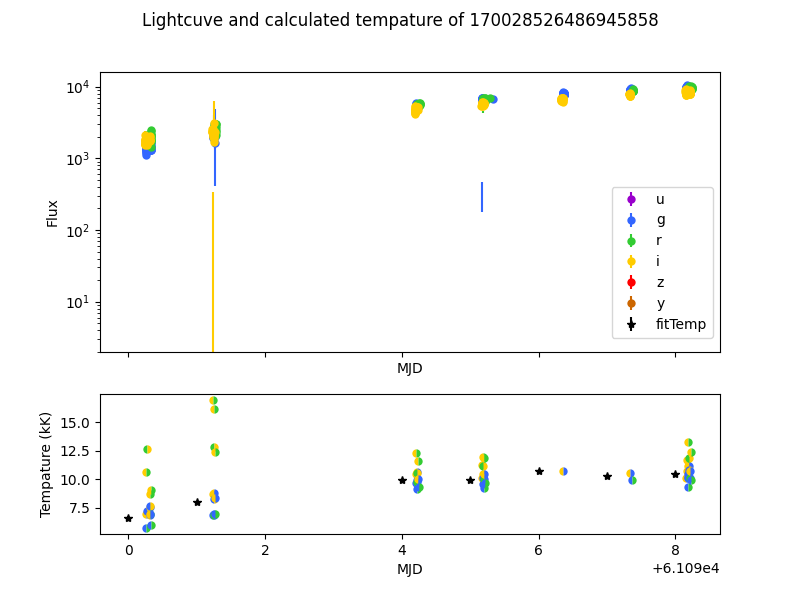

In [12]:
diaObjectId = 170028526486945858

# load the pickled data
with open('object' + str(diaObjectId) + '.pkl', 'rb') as inf: 
    obj = pickle.load(inf)

objList = combinedSources(obj)

c = SkyCoord(obj.ra, obj.dec, unit="deg", frame='icrs')

# The third argument is a distence
# It seems to have no affect since SFD is 2D not 3D but it is a required field
# I pass a large distence (100 kpc) in case it matters at some locations
ebv = sfd_map(c.galactic.l.deg, c.galactic.b.deg, 100)[0]

plotTemp(diaObjectId, objList, ebv)